<a href="https://colab.research.google.com/github/uppupushpa/practice/blob/main/Eda_%26_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from google.colab import files
uploaded=files.upload()

Saving heights_new.csv to heights_new.csv


In [14]:
import pandas as pd
df = pd.read_csv("heights_new.csv")
df

,name,height
0,pushpa,1.2
1,bhavya,2.3
2,lokesh,4.9
3,shilpa,5.1
4,shileela,5.2
5,pooja,5.4
6,shivani,5.5
7,varshini,5.5
8,sathvika,5.6
9,kalyani,5.6


In [15]:
df.describe()

,height
count,21.000000
mean,8.233333
std,8.590479
min,1.200000
25%,5.200000
50%,5.600000
75%,6.200000
max,40.200000


In [16]:
#Detect outliers using IQR
Q1 = df.height.quantile(0.25)
Q3 = df.height.quantile(0.75)
Q1, Q3

(np.float64(5.2), np.float64(6.2))

In [17]:
IQR=Q3-Q1
IQR

np.float64(1.0)

In [18]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(3.7), np.float64(7.7))

In [19]:
#outliers

df[(df.height<lower_limit)|(df.height>upper_limit)]

,name,height
0,pushpa,1.2
1,bhavya,2.3
17,mouni,14.5
18,pravalika,23.2
19,harika,40.2


In [20]:
#Remove outliers
df_no_outlier = df[(df.height>lower_limit)&(df.height<upper_limit)]
df_no_outlier

,name,height
2,lokesh,4.9
3,shilpa,5.1
4,shileela,5.2
5,pooja,5.4
6,shivani,5.5
7,varshini,5.5
8,sathvika,5.6
9,kalyani,5.6
10,sowji,5.8
11,komali,5.9


#Task:
You are given height_weight.csv file which contains heights and weights of 1000 people. Dataset is taken from here, https://www.kaggle.com/mustafaali96/weight-height

You need to do this,

(1) Load this csv in pandas dataframe and first plot histograms for height and weight parameters

(2) Using IQR detect weight outliers and print them

(3) Using IQR, detect height outliers and print them

(4) replace the outliers with mean and median  and print the dataset


In [23]:
from google.colab import files
uploaded = files.upload()

Saving weight-height.csv to weight-height.csv


In [32]:
#Load the dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("weight-height.csv")   # Replace with your uploaded file name if different

print(df.head())

  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801


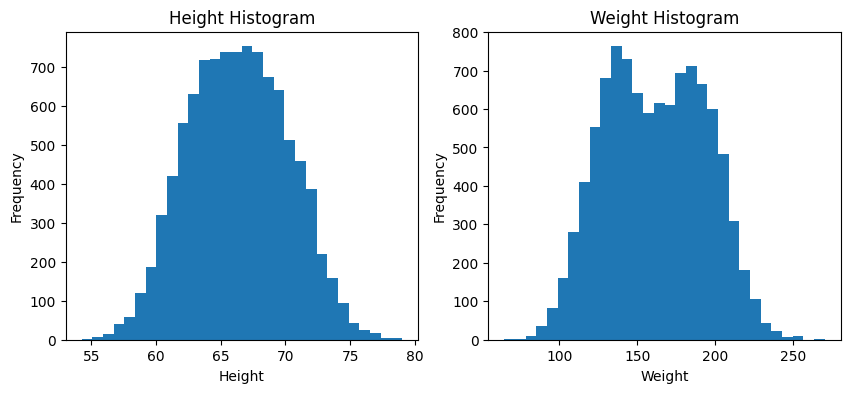

In [33]:
#Plot Histograms
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df["Height"], bins=30)
plt.title("Height Histogram")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(df["Weight"], bins=30)
plt.title("Weight Histogram")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.show()

In [34]:
#Detect Weight Outliers (IQR)
Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

weight_outliers = df[(df["Weight"] < lower) | (df["Weight"] > upper)]
print(weight_outliers)

     Gender     Height      Weight
2014   Male  78.998742  269.989699


In [35]:
#Detect Height Outliers (IQR)
Q1 = df["Height"].quantile(0.25)
Q3 = df["Height"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

height_outliers = df[(df["Height"] < lower) | (df["Height"] > upper)]

print("Height Outliers:")
print(height_outliers)

Height Outliers:
      Gender     Height      Weight
994     Male  78.095867  255.690835
1317    Male  78.462053  227.342565
2014    Male  78.998742  269.989699
3285    Male  78.528210  253.889004
3757    Male  78.621374  245.733783
6624  Female  54.616858   71.393749
7294  Female  54.873728   78.606670
9285  Female  54.263133   64.700127


In [36]:
#Replace Outliers with Mean
df_mean = df.copy()

# Weight
mean_weight = df["Weight"].mean()

Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_mean.loc[(df_mean["Weight"] < lower) | (df_mean["Weight"] > upper), "Weight"] = mean_weight

# Height
mean_height = df["Height"].mean()

Q1 = df["Height"].quantile(0.25)
Q3 = df["Height"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_mean.loc[(df_mean["Height"] < lower) | (df_mean["Height"] > upper), "Height"] = mean_height

print(df_mean)

      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [37]:
#Replace Outliers with Median
df_median = df.copy()

# Weight
median_weight = df["Weight"].median()

Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_median.loc[(df_median["Weight"] < lower) | (df_median["Weight"] > upper), "Weight"] = median_weight

# Height
median_height = df["Height"].median()

Q1 = df["Height"].quantile(0.25)
Q3 = df["Height"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_median.loc[(df_median["Height"] < lower) | (df_median["Height"] > upper), "Height"] = median_height

print(df_median)

      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]
